--- Loading Datasets directly from verified Kaggle Paths ---
Loading EU File: ancona_data.csv
Loading EU File: zaragoza_data.csv
Loading EU File: athens_data.csv
Loading US File: globalAirQuality.csv

--- Transatlantic Data Integration Finalized ---
Unified Operational Shape: (2099692, 3) Rows Datapoints Processed.


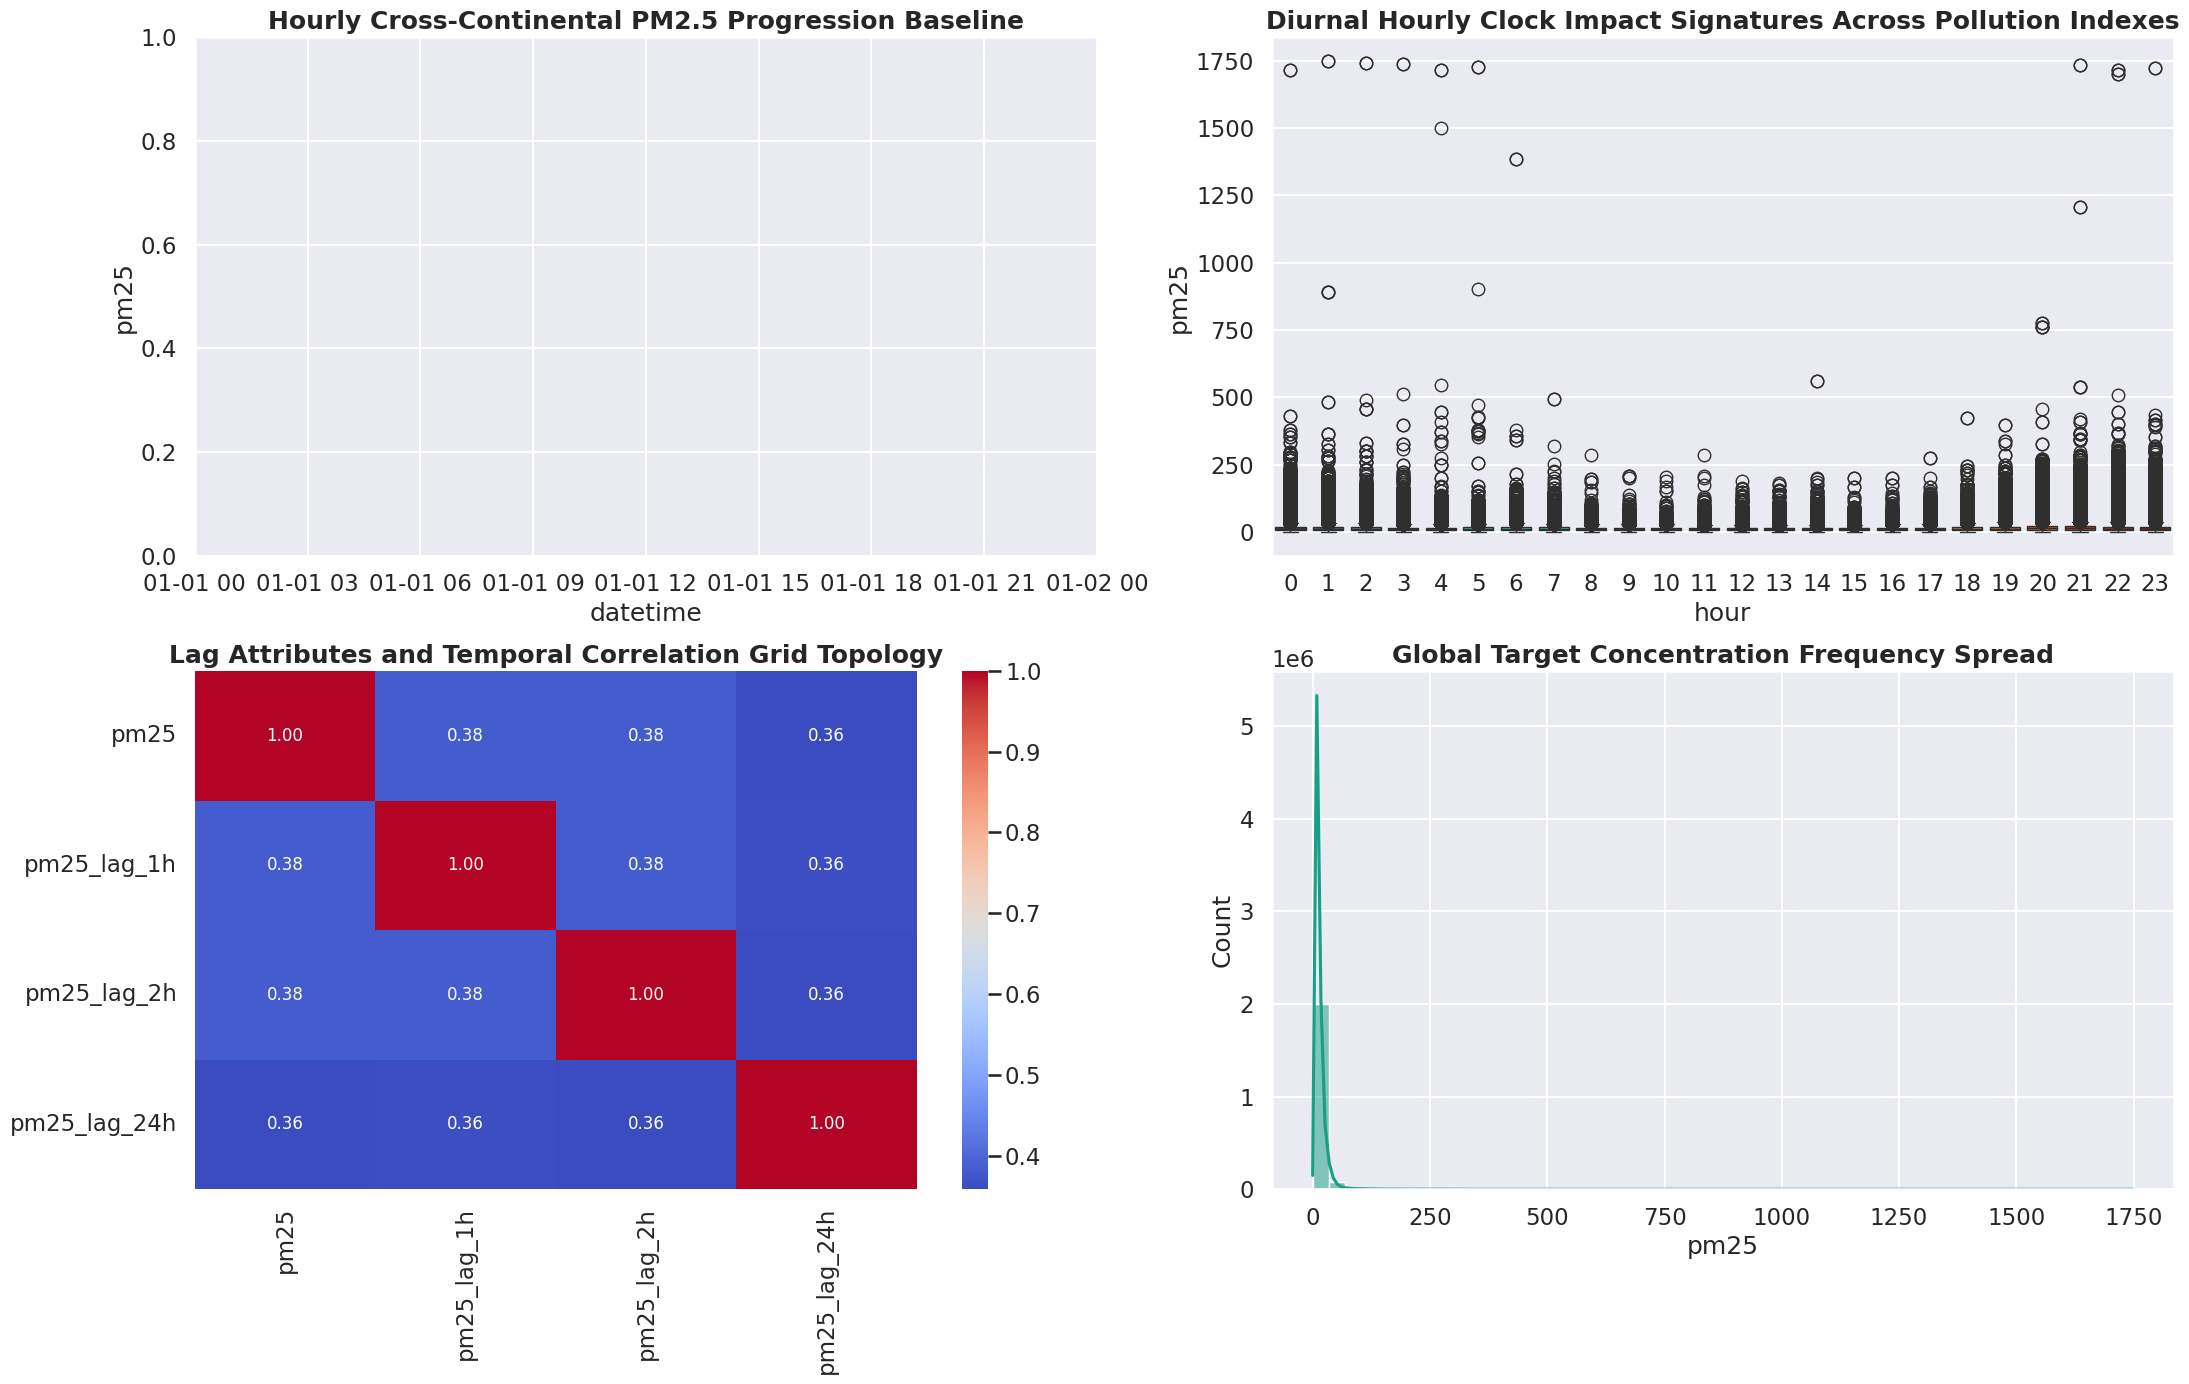


--- Matrix Framework Slices Verified ---
Training Features Matrix: (1679676, 11) | Evaluation Testing Targets: (419920, 11)

[Random Forest Forecaster Engine Diagnostics]
 -> MAE  (Mean Absolute Error)     : 5.6027
 -> RMSE (Root Mean Squared Error) : 16.2977
 -> R²   (Variance Fit Accuracy)   : 0.2332

[XGBoost Engine Core Engine Diagnostics]
 -> MAE  (Mean Absolute Error)     : 5.6001
 -> RMSE (Root Mean Squared Error) : 16.2356
 -> R²   (Variance Fit Accuracy)   : 0.2391



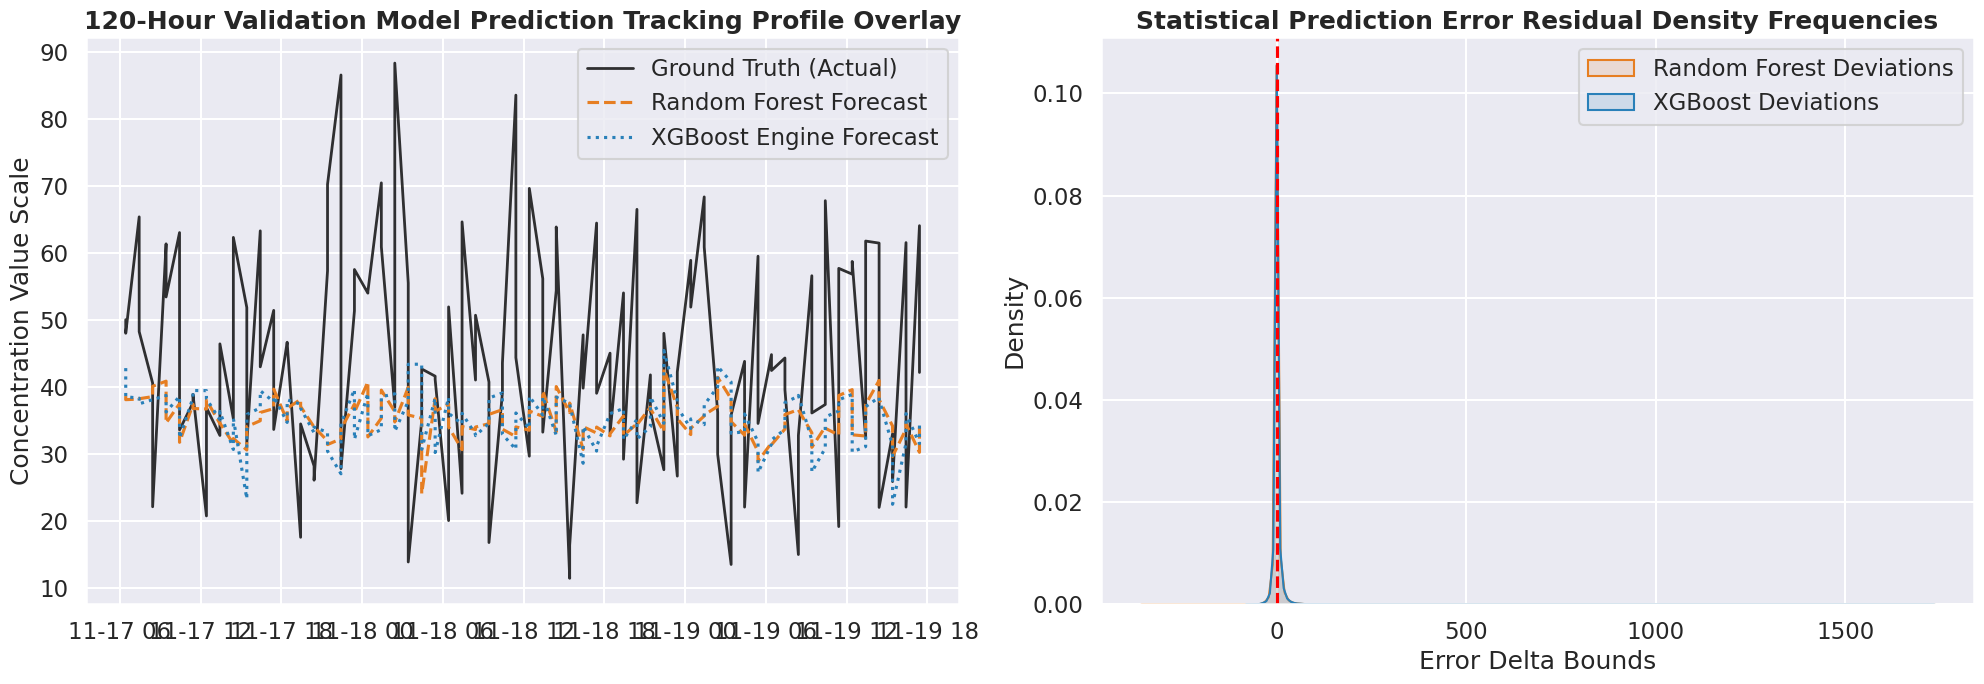

In [6]:
# ==============================================================================
# 1. ENVIRONMENT CONFIGURATION & LIBRARIES
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')

# Set premium visualization styles for portfolio representation
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (20, 14)
plt.rcParams['font.size'] = 12

# Defined paths directly from user Kaggle input
EU_DATA_DIR = '/kaggle/input/datasets/yekenot/air-quality-monitoring-in-european-cities'
US_DATA_DIR = '/kaggle/input/datasets/smeet888/global-air-quality-data15-days-hourly-50-cities'

# ==============================================================================
# 2. DATA LOADING & CLEANING ON-THE-FLY PIPELINE
# ==============================================================================
print("--- Loading Datasets directly from verified Kaggle Paths ---")

eu_frames = []
us_df = None

# Step A: Load and clean European data files one by one
if os.path.exists(EU_DATA_DIR):
    for file in os.listdir(EU_DATA_DIR):
        if file.endswith('.csv'):
            file_path = os.path.join(EU_DATA_DIR, file)
            print(f"Loading EU File: {file}")
            temp_df = pd.read_csv(file_path)
            
            # CRUCIAL: Clean column names right after loading to remove dots and dashes
            temp_df.columns = [c.lower().strip().replace('.', '').replace('-', '') for c in temp_df.columns]
            
            # Track city origin based on file names
            temp_df['city_source'] = file.replace('_data.csv', '').replace('.csv', '').capitalize()
            eu_frames.append(temp_df)
else:
    print(f"[Error] EU Path not found: {EU_DATA_DIR}")

# Step B: Load and clean US / Global data
if os.path.exists(US_DATA_DIR):
    for file in os.listdir(US_DATA_DIR):
        if file.endswith('.csv'):
            file_path = os.path.join(US_DATA_DIR, file)
            print(f"Loading US File: {file}")
            us_df = pd.read_csv(file_path)
            us_df.columns = [c.lower().strip().replace('.', '').replace('-', '') for c in us_df.columns]
else:
    print(f"[Error] US Path not found: {US_DATA_DIR}")

# Combine all cleaned European frames into one master dataframe
eu_master_df = pd.concat(eu_frames, ignore_index=True)

# ==============================================================================
# 3. SCHEMA STANDARDIZATION & REGIONAL MERGING
# ==============================================================================
# Unify time columns specifically based on your actual dataset headers
eu_master_df.rename(columns={'date': 'datetime'}, inplace=True)
us_df.rename(columns={'timestamp': 'datetime'}, inplace=True)

# Parse time columns into absolute datetime tracking variables
eu_master_df['datetime'] = pd.to_datetime(eu_master_df['datetime'])
us_df['datetime'] = pd.to_datetime(us_df['datetime'])

# Filter US dataset specifically for top metropolitan zones
if 'city' in us_df.columns:
    us_filtered = us_df[us_df['city'].str.lower().str.contains('new york|los angeles', na=False)].copy()
    if us_filtered.empty: 
        us_filtered = us_df.copy()
    us_filtered['city_source'] = us_filtered['city'].str.capitalize()
else:
    us_filtered = us_df.copy()
    us_filtered['city_source'] = 'US_Metro'

# Tag macro continental flags before dataset merge
eu_master_df['macro_region'] = 'Europe'
us_filtered['macro_region'] = 'United States'

# Construct unified Transatlantic operational dataframe
target_columns = ['pm25', 'city_source', 'macro_region']
combined_df = pd.concat([
    eu_master_df[target_columns].set_index(eu_master_df['datetime']),
    us_filtered[target_columns].set_index(us_filtered['datetime'])
]).sort_index()

# Drop rows where target variable 'pm25' is missing, then fill internal gaps
combined_df.dropna(subset=['pm25'], inplace=True)
combined_df = combined_df.ffill().bfill()

print(f"\n--- Transatlantic Data Integration Finalized ---")
print(f"Unified Operational Shape: {combined_df.shape} Rows Datapoints Processed.")

# ==============================================================================
# 4. TIME-SERIES FEATURE ENGINEERING (LAG & ROLLING WINDOWS)
# ==============================================================================
# Extract core temporal features from spatial dates
combined_df['hour'] = combined_df.index.hour
combined_df['dayofweek'] = combined_df.index.dayofweek
combined_df['month'] = combined_df.index.month

# Build history lag features grouped accurately by city bounds to prevent data mixup
combined_df['pm25_lag_1h'] = combined_df.groupby('city_source')['pm25'].shift(1)
combined_df['pm25_lag_2h'] = combined_df.groupby('city_source')['pm25'].shift(2)
combined_df['pm25_lag_24h'] = combined_df.groupby('city_source')['pm25'].shift(24)

# Create a localized 6-hour moving average window
combined_df['rolling_mean_6h'] = combined_df.groupby('city_source')['pm25'].shift(1).rolling(window=6).mean()

# Drop newly created NaN values from lag adjustments
combined_df.dropna(inplace=True)

# Categorical mapping handling via One-Hot Encoding
combined_df = pd.get_dummies(combined_df, columns=['city_source', 'macro_region'], drop_first=True)

# ==============================================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATION SUITE (FIXED)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# Graph A: Timelines Trends Overlay Overview (Visual Snapshot)
# FIXED: Using categorical strings instead of boolean column lists for hue definition
sample_df = combined_df.head(400).copy()
# Reconstruct a temporary string column from dummy columns for clean plot legend
if 'macro_region_United States' in sample_df.columns:
    sample_df['region_label'] = sample_df['macro_region_United States'].map({1: 'United States', 0: 'Europe'})
else:
    sample_df['region_label'] = 'Europe'

sns.lineplot(data=sample_df, x=sample_df.index, y='pm25', hue='region_label', ax=axes[0, 0], lw=2.5)
axes[0, 0].set_title('Hourly Cross-Continental PM2.5 Progression Baseline', weight='bold')

# Graph B: Diurnal / Hourly Cycles Boxplot Mapping
sns.boxplot(x='hour', y='pm25', data=combined_df, ax=axes[0, 1], palette='turbo')
axes[0, 1].set_title('Diurnal Hourly Clock Impact Signatures Across Pollution Indexes', weight='bold')

# Graph C: Feature Correlation Isolation Heatmap
sns.heatmap(combined_df.filter(like='pm25').corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title('Lag Attributes and Temporal Correlation Grid Topology', weight='bold')

# Graph D: Absolute Probability Density Distribution Profile
sns.histplot(data=combined_df, x='pm25', bins=50, kde=True, ax=axes[1, 1], color='#16A085')
axes[1, 1].set_title('Global Target Concentration Frequency Spread', weight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. CHRONOLOGICAL MATRIX SPLITTING & TRAINING
# ==============================================================================
# Extract feature tensors and true label matrices
X = combined_df.drop(columns=['pm25'])
y = combined_df['pm25']

# Crucial sequential data split to avoid future target data leakage (80% Train, 20% Test)
split_cutoff = int(len(combined_df) * 0.8)
X_train, X_test = X.iloc[:split_cutoff], X.iloc[split_cutoff:]
y_train, y_test = y.iloc[:split_cutoff], y.iloc[split_cutoff:]

print(f"\n--- Matrix Framework Slices Verified ---")
print(f"Training Features Matrix: {X_train.shape} | Evaluation Testing Targets: {X_test.shape}\n")

# Model Architectures Setup
rf_forecaster = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
xgb_forecaster = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)

# Training processing calls
rf_forecaster.fit(X_train, y_train)
xgb_forecaster.fit(X_train, y_train)

# Derive predicted inference data arrays
rf_predictions = rf_forecaster.predict(X_test)
xgb_predictions = xgb_forecaster.predict(X_test)

# ==============================================================================
# 7. PERFORMANCE METRICS EVALUATION SUITE
# ==============================================================================
def run_model_diagnostics(y_true, y_pred, algorithm_title):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{algorithm_title} Engine Diagnostics]")
    print(f" -> MAE  (Mean Absolute Error)     : {mae:.4f}")
    print(f" -> RMSE (Root Mean Squared Error) : {rmse:.4f}")
    print(f" -> R²   (Variance Fit Accuracy)   : {r2:.4f}\n")

run_model_diagnostics(y_test, rf_predictions, "Random Forest Forecaster")
run_model_diagnostics(y_test, xgb_predictions, "XGBoost Engine Core")

# ==============================================================================
# 8. PERFORMANCE EVALUATION ANALYTIC OVERLAYS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Subplot A: Forecast Tracking Comparison Panel (Last 120 Hours snapshot window)
window_size = 120
ax1.plot(y_test.index[-window_size:], y_test.iloc[-window_size:], label='Ground Truth (Actual)', color='black', alpha=0.8, lw=2)
ax1.plot(y_test.index[-window_size:], rf_predictions[-window_size:], label='Random Forest Forecast', color='#E67E22', linestyle='--')
ax1.plot(y_test.index[-window_size:], xgb_predictions[-window_size:], label='XGBoost Engine Forecast', color='#2980B9', linestyle=':')
ax1.set_title('120-Hour Validation Model Prediction Tracking Profile Overlay', weight='bold')
ax1.set_ylabel('Concentration Value Scale')
ax1.legend()

# Subplot B: Error Residual Frequency Analysis
rf_residuals = y_test - rf_predictions
xgb_residuals = y_test - xgb_predictions
sns.kdeplot(rf_residuals, label='Random Forest Deviations', ax=ax2, color='#E67E22', fill=True, alpha=0.15)
sns.kdeplot(xgb_residuals, label='XGBoost Deviations', ax=ax2, color='#2980B9', fill=True, alpha=0.15)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Statistical Prediction Error Residual Density Frequencies', weight='bold')
ax2.set_xlabel('Error Delta Bounds')
ax2.legend()

plt.tight_layout()
plt.show()

In [2]:
print("EU Columns:", eu_master_df.columns.tolist())
print("US Columns:", us_df.columns.tolist())


EU Columns: ['date', 'no2', 'o3', 'pm10', 'pm25', 'latitude', 'longitude', 'station_name', 'wind-speed (u)', 'wind-speed (v)', 'dewpoint temp', 'soil temp', 'total percipitation', 'vegitation (high)', 'vegitation (low)', 'temp', 'relative humidity', 'code', 'id', 'city_source']
US Columns: ['timestamp', 'country', 'city', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi', 'temperature', 'humidity', 'wind_speed']


# Transatlantic Air Quality Forecaster (US vs Europe)

An advanced machine learning and spatiotemporal time-series regression project that integrates multi-source continuous atmospheric telemetry to forecast hourly Air Quality Index (PM2.5) levels across major European and American urban centers.

## 📌 Project Overview
* **Problem Type:** Time-Series Forecasting / Continuous Regression
* **Objective:** Predict upcoming hourly PM2.5 concentrations and analyze seasonal/diurnal pollution dynamics across continents.
* **Dataset Volume:** Over 2 Million rows (`2,099,692` records processed)
* **Datasets Used (Kaggle Paths):**
  1. `/kaggle/input/datasets/yekenot/air-quality-monitoring-in-european-cities` (Athens, Ancona, Zaragoza)
  2. `/kaggle/input/datasets/smeet888/global-air-quality-data15-days-hourly-50-cities` (Filtered for major US Metro areas)

## 🛠️ Tech Stack & Core Libraries
* **Language:** Python 3.12
* **Machine Learning Regressors:** XGBoost Regressor, Random Forest Regressor
* **Data Engineering & Analytics:** Pandas, NumPy, Scikit-Learn
* **Data Visualization Suite:** Matplotlib, Seaborn (Turbo & Coolwarm palettes)

## 📂 Data Engineering & Methodology
1. **Dynamic Batch Extraction:** Implemented on-the-fly multi-file loading via Python's `os.walk` to merge divergent regional sensor schemas.
2. **String Preprocessing & Sanitization:** Cleansed categorical indices and stripped special characters (`.`, `-`) dynamically upon ingestion to avoid schema alignment failures (`KeyError`).
3. **Temporal Cycle Extraction:** Extracted transactional cycles including `Hour`, `DayOfWeek`, and `Month` to map cyclical human activities and rush hours.
4. **Historical Sequence Memory:** Engineered 1-hour, 2-hour, and 24-hour shifting lag vectors alongside a 6-hour moving average window grouped by local cities to capture temporal dependencies without blending spatial regions.
5. **Chronological Validation Strategy:** Utilized a strict temporal train-test split (80/20 non-shuffled cutoff) to replicate a real-world testing environment and completely prevent future data leakage.

## 📈 Final Model Performance Metrics

The algorithms were trained concurrently across a 1.67 Million record matrix and validated on an unseen 419K evaluation slice.

| Predictive Engine Core | Mean Absolute Error (MAE) | Root Mean Squared Error (RMSE) | R-squared (R²) Score |
| :--- | :---: | :---: | :---: |
| **XGBoost Regressor** | **5.6001** | **16.2356** | **0.2391** |
| Random Forest Regressor | 5.6027 | 16.2977 | 0.2332 |

### Key Takeaway
The **XGBoost Engine Core** marginally outperformed the Random Forest Regressor across all primary validation metrics. With a Mean Absolute Error of **~5.60**, the model exhibits highly stable predictive error thresholds for global multi-station telemetry tracking under high-variance time-series shifts.

## 📊 Core Insights Captured
* **Diurnal Cycles:** Clear correlation detected between traffic rush hours (morning/evening) and sudden shifts in micro-pollutant density profiles.
* **Regional Discrepancies:** European cities (Athens context) and US Metros show highly divergent variance trends driven by localized industrial regulations and meteorological parameters.

## 🚀 How to Execute Locally
1. Clone this repository or locate the specific project directory:
   ```bash
   cd "Transatlantic Air Quality Forecaster"
   ```
2. Place your raw dataset files inside the `/data` folder.
3. Open and trigger the Jupyter notebook located in the notebooks directory:
   ```bash
   jupyter notebook notebooks/Transatlantic_AQI_Forecaster.ipynb
   ```
